<a href="https://colab.research.google.com/github/priyanka260604/first_gitrepo/blob/main/que1iacv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install opencv-python matplotlib numpy scikit-image scikit-learn pillow

In [3]:
import os

# Extract the CUB_200_2011.tgz file first
!tar -xzf CUB_200_2011.tgz

print(os.listdir("CUB_200_2011"))


gzip: stdin: unexpected end of file
tar: Unexpected EOF in archive
tar: Unexpected EOF in archive
tar: Error is not recoverable: exiting now
['images']


In [4]:
['images', 'attributes', 'classes.txt', ...]

['images', 'attributes', 'classes.txt', Ellipsis]

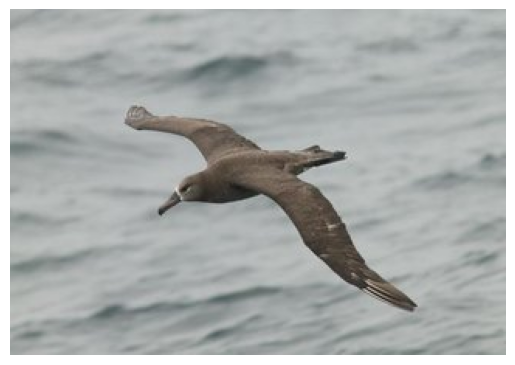

In [21]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0001_796111.jpg")

plt.imshow(img)
plt.axis("off")
plt.show()

In [7]:
pip install pillow matplotlib opencv-python

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim

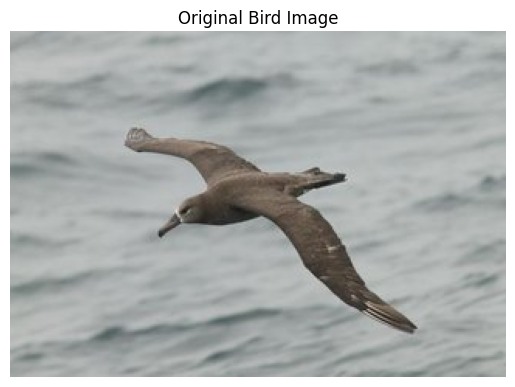

In [10]:
img_path = "CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0001_796111.jpg"
img = cv2.imread(img_path)

if img is None:
    print(f"Error: Could not load image from {img_path}")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.title("Original Bird Image")
    plt.axis("off")
    plt.show()

In [11]:
print("Image Shape =", img.shape)

Image Shape = (223, 320, 3)


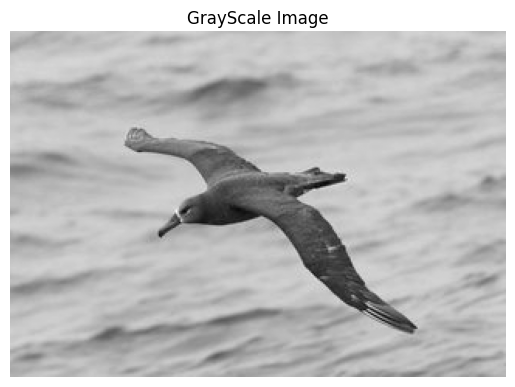

In [12]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("GrayScale Image")
plt.axis("off")
plt.show()

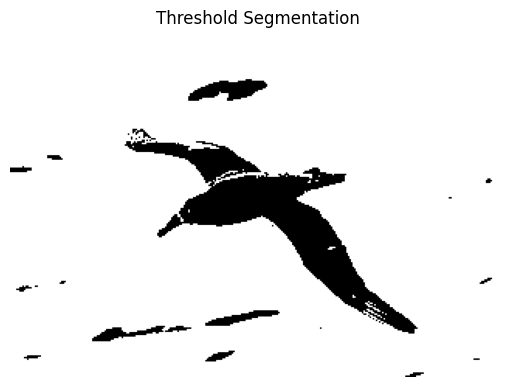

In [13]:
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

plt.imshow(thresh, cmap='gray')
plt.title("Threshold Segmentation")
plt.axis("off")
plt.show()

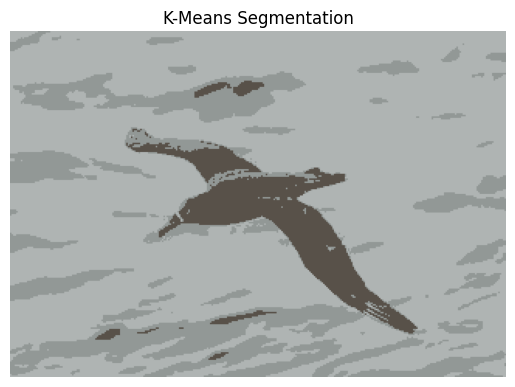

In [14]:
Z = img.reshape((-1,3))

Z = np.float32(Z)

K = 3

criteria = (
    cv2.TERM_CRITERIA_EPS +
    cv2.TERM_CRITERIA_MAX_ITER,
    10,
    1.0
)

ret, label, center = cv2.kmeans(
    Z,
    K,
    None,
    criteria,
    10,
    cv2.KMEANS_RANDOM_CENTERS
)

center = np.uint8(center)

segmented = center[label.flatten()]

segmented = segmented.reshape(img.shape)

segmented_rgb = cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB)

plt.imshow(segmented_rgb)
plt.title("K-Means Segmentation")
plt.axis("off")
plt.show()

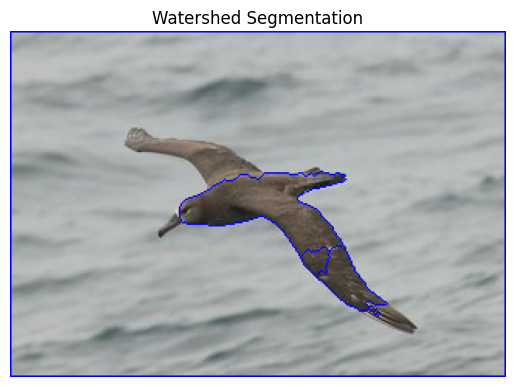

In [15]:
ret, thresh = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

kernel = np.ones((3,3), np.uint8)

opening = cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)

ret, sure_fg = cv2.threshold(
    dist_transform,
    0.7 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

unknown = cv2.subtract(sure_bg, sure_fg)

ret, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1

markers[unknown == 255] = 0

markers = cv2.watershed(img, markers)

img[markers == -1] = [255,0,0]

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Watershed Segmentation")
plt.axis("off")
plt.show()

In [16]:
mse = mean_squared_error(
    gray.flatten(),
    cv2.cvtColor(segmented, cv2.COLOR_BGR2GRAY).flatten()
)

print("MSE =", mse)

MSE = 100.06597533632286


In [17]:
seg_gray = cv2.cvtColor(segmented, cv2.COLOR_BGR2GRAY)

score = ssim(gray, seg_gray)

print("SSIM =", score)

SSIM = 0.7796364338458672


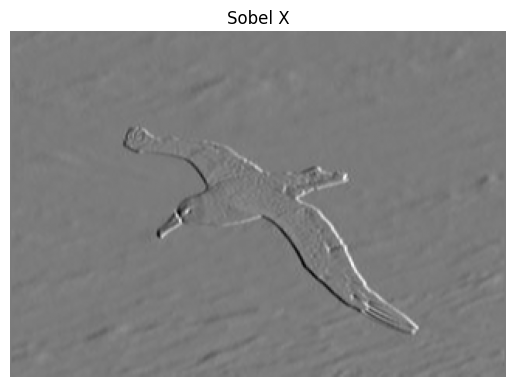

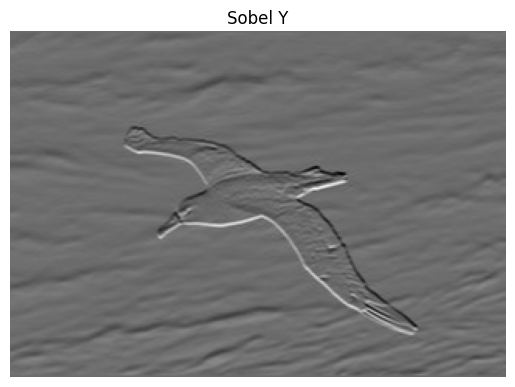

In [18]:
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)

sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

plt.imshow(sobelx, cmap='gray')
plt.title("Sobel X")
plt.axis("off")
plt.show()

plt.imshow(sobely, cmap='gray')
plt.title("Sobel Y")
plt.axis("off")
plt.show()

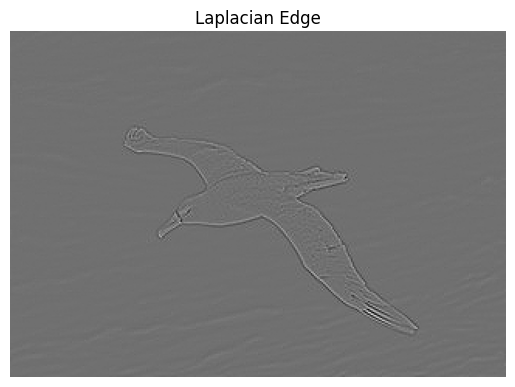

In [19]:
laplacian = cv2.Laplacian(gray, cv2.CV_64F)

plt.imshow(laplacian, cmap='gray')
plt.title("Laplacian Edge")
plt.axis("off")
plt.show()

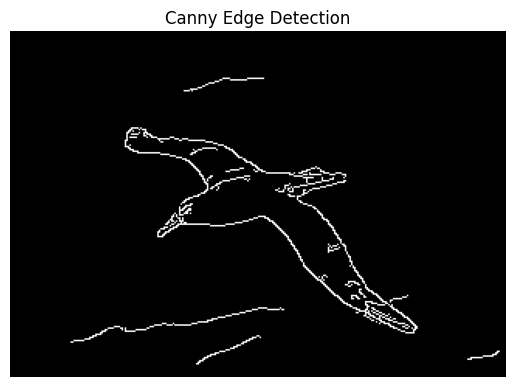

In [20]:
edges = cv2.Canny(gray, 100, 200)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()